# Trading Risk Dashboard - Nasdaq Risk Analysis

## Objective

This notebook analyzes the performance and risk characteristics of the Nasdaq Composite Index.

The goal is to calculate key market risk indicators:
- Returns
- Cumulative performance
- Volatility
- Drawdown
- Sharpe Ratio
- Return distribution statistics

In [17]:
import sys 

!{sys.executable} -m pip list

Package            Version
------------------ ------------
asttokens          3.0.2
beautifulsoup4     4.15.0
certifi            2026.7.22
cffi               2.1.0
charset-normalizer 3.4.9
colorama           0.4.6
comm               0.2.3
contourpy          1.3.2
curl_cffi          0.15.0
cycler             0.12.1
debugpy            1.8.21
decorator          5.3.1
exceptiongroup     1.3.1
executing          2.2.1
fonttools          4.63.0
idna               3.18
ipykernel          7.3.0
ipython            8.39.0
jedi               0.20.0
jupyter_client     8.9.1
jupyter_core       5.9.1
kiwisolver         1.5.0
markdown-it-py     4.2.0
matplotlib         3.10.9
matplotlib-inline  0.2.2
mdurl              0.1.2
multitasking       0.0.13
nest-asyncio2      1.7.2
numpy              2.2.6
packaging          26.2
pandas             2.3.3
parso              0.8.7
peewee             4.2.6
pillow             12.3.0
pip                22.3.1
platformdirs       4.11.0
prompt_toolkit     3.0.53
p


[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
import sys 

!{sys.executable} -m pip install pandas numpy yfinance


[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
import pandas as pd
import yfinance as yf

print("Notebook connecté !")

Notebook connecté !


In [20]:
import sys

print(sys.executable)

c:\Users\ENZO\AppData\Local\Programs\Python\Python310\python.exe


In [21]:
import pandas as pd
import yfinance as yf

print ("Notebook connecté !")

Notebook connecté !


In [22]:
import yfinance as yf
import pandas as pd 

nasdaq = yf.download(
    "^IXIC",
    start="2025-01-01",
    end="2026-01-01"
)
nasdaq.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^IXIC,^IXIC,^IXIC,^IXIC,^IXIC
Date,,,,,
2025-01-02,19280.789062,19517.869141,19117.589844,19403.900391,8737550000
2025-01-03,19621.679688,19638.660156,19379.570312,19395.509766,8214050000
2025-01-06,19864.980469,20007.949219,19785.000000,19851.990234,9586840000
2025-01-07,19489.679688,19940.210938,19421.019531,19938.080078,13371130000
2025-01-08,19478.880859,19544.509766,19308.539062,19469.369141,8851720000


In [23]:
print("test")

test


In [11]:
print(nasdaq.shape)

(250, 5)


In [25]:
nasdaq.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 250 entries, 2025-01-02 to 2025-12-31
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Close, ^IXIC)   250 non-null    float64
 1   (High, ^IXIC)    250 non-null    float64
 2   (Low, ^IXIC)     250 non-null    float64
 3   (Open, ^IXIC)    250 non-null    float64
 4   (Volume, ^IXIC)  250 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.7 KB


In [14]:
print(nasdaq.columns)

MultiIndex([( 'Close', '^IXIC'),
            (  'High', '^IXIC'),
            (   'Low', '^IXIC'),
            (  'Open', '^IXIC'),
            ('Volume', '^IXIC')],
           names=['Price', 'Ticker'])


In [26]:
nasdaq.columns = nasdaq.columns.droplevel(1)

print(nasdaq.columns)

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


In [27]:
nasdaq["Return"] = nasdaq["Close"].pct_change()

print(nasdaq.head())

Price              Close          High           Low          Open  \
Date                                                                 
2025-01-02  19280.789062  19517.869141  19117.589844  19403.900391   
2025-01-03  19621.679688  19638.660156  19379.570312  19395.509766   
2025-01-06  19864.980469  20007.949219  19785.000000  19851.990234   
2025-01-07  19489.679688  19940.210938  19421.019531  19938.080078   
2025-01-08  19478.880859  19544.509766  19308.539062  19469.369141   

Price            Volume    Return  
Date                               
2025-01-02   8737550000       NaN  
2025-01-03   8214050000  0.017680  
2025-01-06   9586840000  0.012400  
2025-01-07  13371130000 -0.018893  
2025-01-08   8851720000 -0.000554  


In [28]:
volatility = nasdaq["Return"].std()

print(volatility)

0.01538273291422182


Objectif : récuperer des données financières, calculer des indicateurs de risque et préparer les données nécessaires à un dashboard de trading. 

In [29]:
nasdaq["Cumulative Return"] = (1 + nasdaq["Return"]).cumprod() - 1

print(nasdaq.head())

Price              Close          High           Low          Open  \
Date                                                                 
2025-01-02  19280.789062  19517.869141  19117.589844  19403.900391   
2025-01-03  19621.679688  19638.660156  19379.570312  19395.509766   
2025-01-06  19864.980469  20007.949219  19785.000000  19851.990234   
2025-01-07  19489.679688  19940.210938  19421.019531  19938.080078   
2025-01-08  19478.880859  19544.509766  19308.539062  19469.369141   

Price            Volume    Return  Cumulative Return  
Date                                                  
2025-01-02   8737550000       NaN                NaN  
2025-01-03   8214050000  0.017680           0.017680  
2025-01-06   9586840000  0.012400           0.030299  
2025-01-07  13371130000 -0.018893           0.010834  
2025-01-08   8851720000 -0.000554           0.010274  


In [30]:
print(nasdaq[["Return", "Cumulative Return"]].head())

Price         Return  Cumulative Return
Date                                   
2025-01-02       NaN                NaN
2025-01-03  0.017680           0.017680
2025-01-06  0.012400           0.030299
2025-01-07 -0.018893           0.010834
2025-01-08 -0.000554           0.010274


In [31]:
print(nasdaq["Return"].std())

0.01538273291422182


In [32]:
print(nasdaq["Cumulative Return"].tail())

Date
2025-12-24    0.224707
2025-12-26    0.223658
2025-12-29    0.217499
2025-12-30    0.214633
2025-12-31    0.205448
Name: Cumulative Return, dtype: float64


In [33]:
final_return = nasdaq["Cumulative Return"].iloc[-1]

print(f"Rendement cumulé : {final_return:.2%}")

Rendement cumulé : 20.54%


In [34]:
nasdaq["Running Max"] = nasdaq["Close"].cummax()

print(nasdaq.head())

Price              Close          High           Low          Open  \
Date                                                                 
2025-01-02  19280.789062  19517.869141  19117.589844  19403.900391   
2025-01-03  19621.679688  19638.660156  19379.570312  19395.509766   
2025-01-06  19864.980469  20007.949219  19785.000000  19851.990234   
2025-01-07  19489.679688  19940.210938  19421.019531  19938.080078   
2025-01-08  19478.880859  19544.509766  19308.539062  19469.369141   

Price            Volume    Return  Cumulative Return   Running Max  
Date                                                                
2025-01-02   8737550000       NaN                NaN  19280.789062  
2025-01-03   8214050000  0.017680           0.017680  19621.679688  
2025-01-06   9586840000  0.012400           0.030299  19864.980469  
2025-01-07  13371130000 -0.018893           0.010834  19864.980469  
2025-01-08   8851720000 -0.000554           0.010274  19864.980469  


In [35]:
nasdaq["Running Max"] = nasdaq["Close"].cummax()

print(nasdaq.head())

Price              Close          High           Low          Open  \
Date                                                                 
2025-01-02  19280.789062  19517.869141  19117.589844  19403.900391   
2025-01-03  19621.679688  19638.660156  19379.570312  19395.509766   
2025-01-06  19864.980469  20007.949219  19785.000000  19851.990234   
2025-01-07  19489.679688  19940.210938  19421.019531  19938.080078   
2025-01-08  19478.880859  19544.509766  19308.539062  19469.369141   

Price            Volume    Return  Cumulative Return   Running Max  
Date                                                                
2025-01-02   8737550000       NaN                NaN  19280.789062  
2025-01-03   8214050000  0.017680           0.017680  19621.679688  
2025-01-06   9586840000  0.012400           0.030299  19864.980469  
2025-01-07  13371130000 -0.018893           0.010834  19864.980469  
2025-01-08   8851720000 -0.000554           0.010274  19864.980469  


In [36]:
nasdaq["Drawdown"] = (
    nasdaq["Close"] - nasdaq["Running Max"]
) / nasdaq["Running Max"]

print(nasdaq[["Close", "Running Max", "Drawdown"]].head())

Price              Close   Running Max  Drawdown
Date                                            
2025-01-02  19280.789062  19280.789062  0.000000
2025-01-03  19621.679688  19621.679688  0.000000
2025-01-06  19864.980469  19864.980469  0.000000
2025-01-07  19489.679688  19864.980469 -0.018893
2025-01-08  19478.880859  19864.980469 -0.019436


In [37]:
max_drawdown = nasdaq["Drawdown"].min()

print(max_drawdown)

-0.2387455204113431


In [38]:
print(f"Maximum Drawdown : {max_drawdown:.2%}")

Maximum Drawdown : -23.87%


In [39]:
worst_date = nasdaq["Drawdown"].idxmin()

print(worst_date)

2025-04-08 00:00:00


## Visualisation du prix du Nasdaq

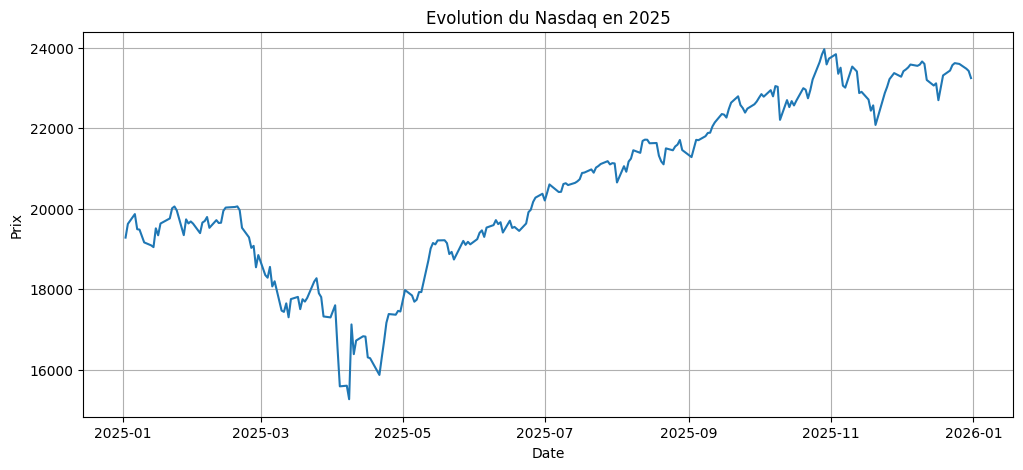

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(nasdaq.index, nasdaq["Close"])

plt.title("Evolution du Nasdaq en 2025")
plt.xlabel("Date")
plt.ylabel("Prix")

plt.grid(True)
plt.show()

In [36]:
import sys

!{sys.executable} -m pip install matplotlib

  Using cached matplotlib-3.10.9-cp310-cp310-win_amd64.whl (8.2 MB)
  Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
  Using cached pillow-12.3.0-cp310-cp310-win_amd64.whl (7.2 MB)
  Using cached kiwisolver-1.5.0-cp310-cp310-win_amd64.whl (73 kB)
  Using cached fonttools-4.63.0-cp310-cp310-win_amd64.whl (1.6 MB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
  Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl (221 kB)



[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


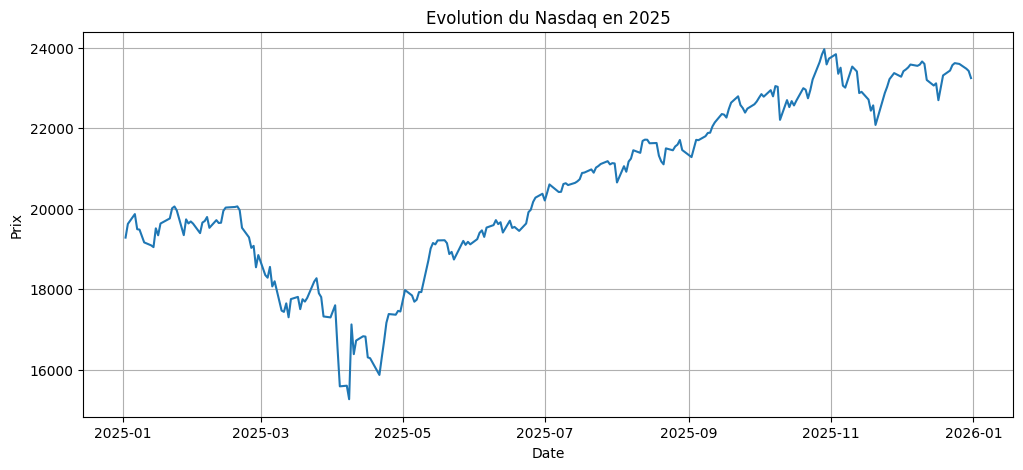

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(nasdaq.index, nasdaq["Close"])

plt.title("Evolution du Nasdaq en 2025")
plt.xlabel("Date")
plt.ylabel("Prix")

plt.grid(True)
plt.show()

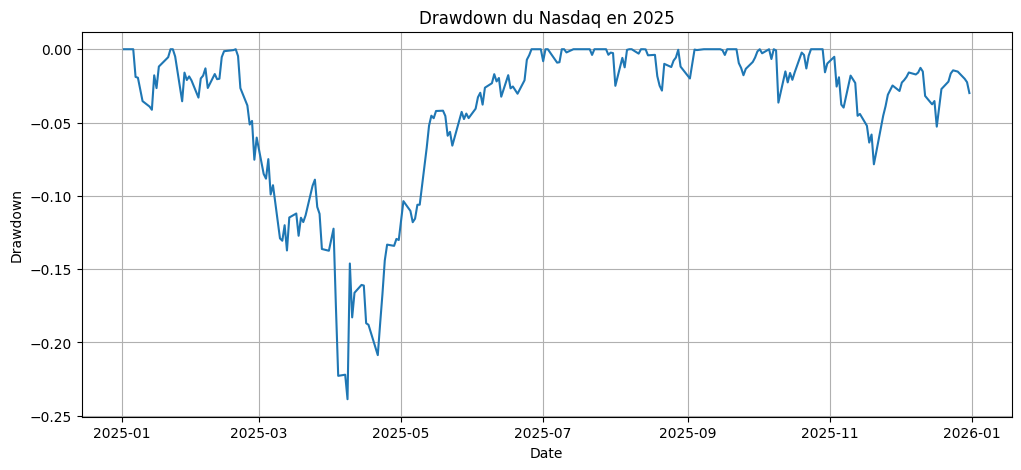

In [42]:
plt.figure(figsize=(12, 5))

plt.plot(nasdaq.index, nasdaq["Drawdown"])

plt.title("Drawdown du Nasdaq en 2025")
plt.xlabel("Date")
plt.ylabel("Drawdown")

plt.grid(True)
plt.show()

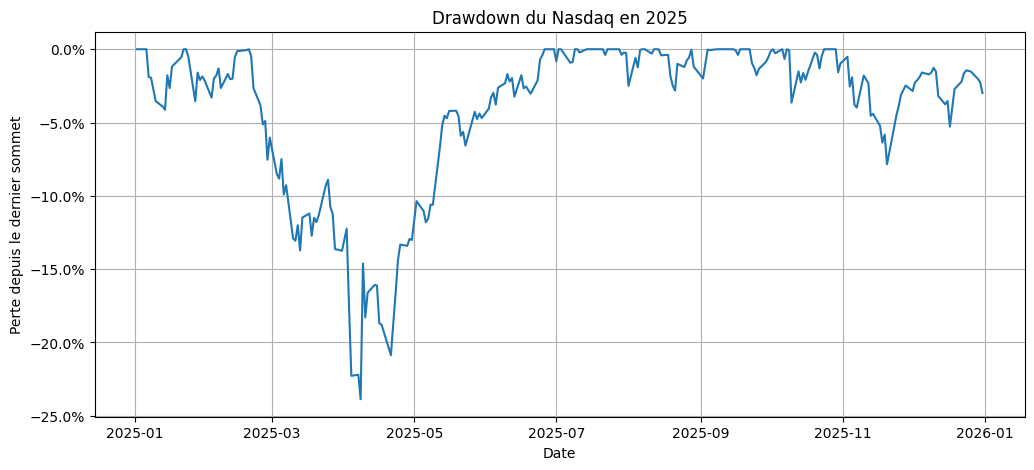

In [43]:
import matplotlib.ticker as mtick

plt.figure(figsize=(12, 5))

plt.plot(nasdaq.index, nasdaq["Drawdown"])

plt.title("Drawdown du Nasdaq en 2025")
plt.xlabel("Date")
plt.ylabel("Perte depuis le dernier sommet")

plt.gca().yaxis.set_major_formatter(
    mtick.PercentFormatter(1)
)

plt.grid(True)
plt.show()

In [44]:
# Performance totale

total_return = nasdaq["Cumulative Return"].iloc[-1]

# Volatilité annualisée

volatility = nasdaq["Return"].std() * (252 ** 0.5)

# Maximum Drawdown

max_drawdown = nasdaq["Drawdown"].min()

print(f"Performance totale : {total_return:.2%}")
print(f"Volatilité annualisée : {volatility:.2%}")
print(f"Maximum Drawdown : {max_drawdown:.2%}")

Performance totale : 20.54%
Volatilité annualisée : 24.42%
Maximum Drawdown : -23.87%


In [45]:
best_day = nasdaq["Return"].max()
worst_day = nasdaq["Return"].min()

print(f"Meilleur jour: {best_day:.2%}")
print(f"Pire jour: {worst_day:.2%}")

Meilleur jour: 12.16%
Pire jour: -5.97%


In [46]:
best_date = nasdaq["Return"].idxmax()
worst_date = nasdaq["Return"].idxmin()

print(f"Meilleur jour : {best_date.date()} ({best_day:.2%})")
print(f"Pire jour : {worst_date.date()} ({worst_day:.2%})")

Meilleur jour : 2025-04-09 (12.16%)
Pire jour : 2025-04-03 (-5.97%)


In [47]:
positive_days = (nasdaq["Return"] > 0).sum()
negative_days = (nasdaq["Return"] < 0).sum()

print(f"Jours positifs : {positive_days}")
print(f"Jours négatifs : {negative_days}")

Jours positifs : 145
Jours négatifs : 104


In [48]:
total_days = nasdaq["Return"].count()

win_rate = positive_days / total_days

print(f"Jours positis : {win_rate:.2%}")

Jours positis : 58.23%


In [49]:
average_return = nasdaq["Return"].mean()

daily_volatility = nasdaq["Return"].std()

sharpe_ratio = (
    average_return / daily_volatility
) * (252 ** 0.5)

print(f"Sharpe Ratio : {sharpe_ratio:.2f}")

Sharpe Ratio : 0.89


Le Nasdaq a affiché une performance anuelle de plus de 20%, mais le sharpe de 0.89 indique que cette performance s'est accompagné d'une volatilité importante. Le rendement ajusté du riqu est donc correc, sans etre exceptionnel. 

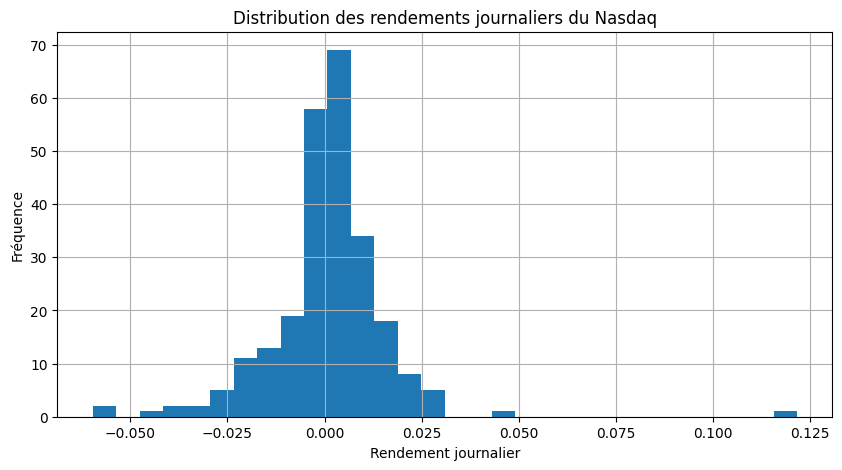

In [50]:
plt.figure(figsize=(10, 5))

plt.hist(nasdaq["Return"].dropna(), bins=30)

plt.title("Distribution des rendements journaliers du Nasdaq")
plt.xlabel("Rendement journalier")
plt.ylabel("Fréquence")

plt.grid(True)

plt.show()

In [51]:
nasdaq.loc[nasdaq["Return"].idxmax()]

Price
Close                1.712497e+04
High                 1.720294e+04
Low                  1.527028e+04
Open                 1.529544e+04
Volume               1.347974e+10
Return               1.216316e-01
Cumulative Return   -1.118117e-01
Running Max          2.005625e+04
Drawdown            -1.461529e-01
Name: 2025-04-09 00:00:00, dtype: float64

In [52]:
skewness = nasdaq["Return"].skew()
kurtosis = nasdaq["Return"].kurtosis()

print(f"Skewness : {skewness:.2f}")
print(f"Kurtosis : {kurtosis:.2f}")

Skewness : 1.25
Kurtosis : 16.36


Le Nasdaq a enregistré une performance annuelle élevée, mais la distribution des rendements n'est pas gaussienne. Les rendements présentent une asymétrie positive, indiquant que quelques journées de très forte hausse ont contribué de manière significative à la performance. Le kurtosis très élevé révèle la présence d'événements extrêmes, confirmant que les mouvements exceptionnels jouent un rôle important dans la dynamique du marché.

In [53]:
assets = yf.download(
    ["^IXIC", "BZ=F", "GC=F"],
    start="2025-01-01",
    end="2026-01-01"
)["Close"]

assets.head()

Failed to get ticker 'BZ=F' reason: Failed to perform, curl: (6) Could not resolve host: query2.finance.yahoo.com. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.
[                       0%                       ]Failed to get ticker 'GC=F' reason: Failed to perform, curl: (6) Could not resolve host: query2.finance.yahoo.com. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.
[*********************100%***********************]  3 of 3 completed

2 Failed downloads:
['BZ=F', 'GC=F']: DNSError('Failed to perform, curl: (6) Could not resolve host: query2.finance.yahoo.com. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')


Ticker,BZ=F,GC=F,^IXIC
Date,,,
2025-01-02,NaN,NaN,19280.789062
2025-01-03,NaN,NaN,19621.679688
2025-01-06,NaN,NaN,19864.980469
2025-01-07,NaN,NaN,19489.679688
2025-01-08,NaN,NaN,19478.880859


# Conclusion

This analysis provides a quantitative overview of Nasdaq market behavior during 2025.

Key observations:

- The Nasdaq generated a positive annual performance.
- Volatility remained significant, reflecting periods of strong market movements.
- Maximum drawdown highlights the importance of risk management during market corrections.
- The Sharpe Ratio shows the efficiency of the return generated relative to the risk taken.
- Return distribution analysis reveals the presence of extreme events through skewness and high kurtosis.

These indicators provide a foundation for understanding market risk and will be integrated into the Trading Risk Dashboard application.